In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt
from matplotlib import gridspec
import string
import re
import os

In [2]:
#make a dictionary of amino acid codes
aa_dict = pd.read_csv("AA_codes.txt", sep = "\t").set_index("Abbreviation").to_dict()
aa_dict = aa_dict["1_letter_abbreviation"]
aa_dict

{'Ala': 'A',
 'Arg': 'R',
 'Asn': 'N',
 'Asp': 'D',
 'Cys': 'C',
 'fMet': 'fM',
 'Gln': 'Q',
 'Glu': 'E',
 'Gly': 'G',
 'His': 'H',
 'Ile': 'I',
 'Leu': 'L',
 'Lys': 'K',
 'Met': 'M',
 'Phe': 'F',
 'Pro': 'P',
 'Ser': 'S',
 'Thr': 'T',
 'Trp': 'W',
 'Tyr': 'Y',
 'Val': 'V'}

In [3]:
def missing(lst1,lst2):
    missing=[]
    list2=lst2.split(", ")
    for item in lst1:
        if item not in list2:
            missing.append(item)
        elif item in list2:
            continue
        else:
            print("Not present or absent?!? Consult Schrodinger and/or his cats.Leave Pavlov's dog out of it.")
    m=", ".join(missing)
    return(m)

def unique(list):
    x = np.array(list)
    return(np.unique(x)) 

def readtrnascan(testdata):
    if os.stat(testdata).st_size != 0:
        df = pd.read_csv(testdata, sep = "\t", header = None)[[1]]
        df.rename(columns={df.columns[0]: 'tRNA'}, inplace=True)
        df["Species"]= re.split("_",os.path.basename(testdata))[0]
        df["Genome"]=re.split("_",os.path.basename(testdata))[1]
        df["anticodon"] = df["tRNA"].apply(lambda x: re.split("-",x)[1]).replace("T","U",regex=True)
        df["enzyme"] = df["tRNA"].apply(lambda x: re.split("-",x)[0]).replace(aa_dict, regex= True)
        df['tRNA'] = df[['enzyme','anticodon']].agg('-'.join, axis=1)
        df =df.drop(columns = ['enzyme','anticodon'])
        return(df)
    else:
        print("File is empty")
        pass

In [4]:
#Import data about tRNAs from gbk files
dirlist= ["gbk/"]
alltRNAs = pd.DataFrame()
for directory in dirlist:
    for file in os.listdir(directory):
        if 'tRNA.tab' in file:
            print("processing ","".join([directory,file]))
            data = readtrnascan("".join([directory,file]))
            if not alltRNAs.empty:
                alltRNAs= pd.concat([alltRNAs, data])
            else:
                alltRNAs = data
        else:
            continue
alltRNAs['Present'] = 2 #2 indicates "present"
unique(alltRNAs["tRNA"])
alltRNAs

processing  gbk/Athaliana_mitochondrion_NC_037304.1_tRNA.tab
processing  gbk/Athaliana_plastid_NC_000932.1_edittRNA.tab
processing  gbk/Bfungosa_plastid_MN414176.1_tRNA.tab
File is empty
processing  gbk/Eaphyllum_plastid_NC_026449.1_tRNA.tab
processing  gbk/Eroseum_plastid_NC_026448.1_tRNA.tab
processing  gbk/Hmonotropa_mitochondrion_MK990822.1toMK990823.1_edittRNA.tab
processing  gbk/Hmonotropa_plastid_KU878156.1_edittRNA.tab
processing  gbk/Rcantleyi_mitochondrion__tRNA.tab
processing  gbk/Rphalloides_mitochondrion_MZ269392toMZ269412_edttRNA.tab
processing  gbk/Rphalloides_plastid_MZ269413.1_tRNA.tab
File is empty
processing  gbk/Shimilayana_mitochondrion__tRNA.tab
processing  gbk/viscumalbum_plastid_KT003925.1_tRNA.tab
File is empty


,tRNA,Species,Genome,Present
0,trnK-UUU,Athaliana,mitochondrion,2
1,trnS-GCU,Athaliana,mitochondrion,2
2,trnP-UGG,Athaliana,mitochondrion,2
3,trnC-GCA,Athaliana,mitochondrion,2
4,trnN-GUU,Athaliana,mitochondrion,2
...,...,...,...,...
2,trnP-UGG,Shimilayana,mitochondrion,2
3,trnS-GCU,Shimilayana,mitochondrion,2
4,trnS-UGA,Shimilayana,mitochondrion,2
5,trnY-GUA,Shimilayana,mitochondrion,2


In [5]:
#Find the missing tRNAs in the plastome
speciesplas=['Athaliana','Hmonotropa','Eroseum','Eaphyllum','Rphalloides','Bfungosa','Rcantleyi', 'Shimilayana']
combosplas=alltRNAs.loc[alltRNAs.Genome.isin(['plastid']),["tRNA","Genome","Species"]].groupby(["tRNA","Genome"]).agg({
   'Species':', '.join
})
combosplas
combosplas['Absent'] = combosplas.loc[:,"Species"].apply(lambda x:missing(speciesplas,x))    
absentplas= combosplas.drop(columns='Species').loc[combosplas['Absent'] != "",:]
absentplas2 = pd.DataFrame(absentplas.Absent.str.split(', ').tolist(), index=absentplas.index).stack().reset_index(['tRNA','Genome']).rename(columns= {0 : 'Species'})
absentplas2[['Present']] = "1" #"1 indicates absence"

#Find tRNAs missing from the mitogenome
speciesmit=['Athaliana','Hmonotropa','Rphalloides','Rcantleyi', 'Shimilayana']
combosmit=alltRNAs.loc[alltRNAs.Genome.isin(['mitochondrion']),["tRNA","Genome","Species"]].groupby(["tRNA","Genome"]).agg({
   'Species':', '.join
})
combosmit['Absent'] = combosmit.loc[:,"Species"].apply(lambda x:missing(speciesmit,x))    
absentmit= combosmit.drop(columns='Species').loc[combosmit['Absent'] != "",:]
absentmit2 = pd.DataFrame(absentmit.Absent.str.split(', ').tolist(), index=absentmit.index).stack().reset_index(['tRNA', 'Genome']).rename(columns= {0 : 'Species'})
absentmit2[['Present']] = "1"

#merge all information into 1 table
absent = pd.concat([absentmit2,absentplas2])
alltRNAs= pd.concat([alltRNAs,absent])
alltRNAs

,tRNA,Species,Genome,Present
0,trnK-UUU,Athaliana,mitochondrion,2
1,trnS-GCU,Athaliana,mitochondrion,2
2,trnP-UGG,Athaliana,mitochondrion,2
3,trnC-GCA,Athaliana,mitochondrion,2
4,trnN-GUU,Athaliana,mitochondrion,2
...,...,...,...,...
3,trnY-GUA,Shimilayana,plastid,1
0,trnfM-CAU,Rphalloides,plastid,1
1,trnfM-CAU,Bfungosa,plastid,1
2,trnfM-CAU,Rcantleyi,plastid,1


In [6]:
#Wrangle tRNA table for plotting
plot_tRNAs =alltRNAs[['Genome','tRNA','Species','Present']].drop_duplicates() #don't need info on redundant tRNAs
plot_tRNAs=plot_tRNAs.pivot(index=['Genome','tRNA'],columns='Species', values='Present').applymap(lambda x: float(x))
plot_tRNAs= plot_tRNAs.reset_index().rename(columns ={
    'Athaliana': 'A. thaliana',
    'Bfungosa' : 'B. fungosa',
    'Eaphyllum' : 'E. aphyllum',
    'Eroseum' : 'E. roseum',
    'Hmonotropa' : 'M. hypopitys',
    'Mesc' : 'M. esculenta',
    'Pequestris' : 'P. equestris',
    'Rcantleyi': 'R. cantleyi',
    'Rphalloides': 'R. phalloides',
    'Rwill' : 'R. williamsianum',
    'Salbum': 'S. album',
    'Shimilayana': 'S. himalayana'
    })
plot_tRNAs2 = plot_tRNAs[['Genome','tRNA','A. thaliana','E. aphyllum','E. roseum','R. cantleyi','S. himalayana','R. phalloides','B. fungosa','M. hypopitys']].sort_values(['Genome','tRNA']).set_index(['tRNA']).fillna(0)

#split df by organelle
chloro_tRNAs = plot_tRNAs2.loc[plot_tRNAs2['Genome']== 'plastid'].drop(columns=['Genome'])
mito_tRNAs = plot_tRNAs2.loc[plot_tRNAs2['Genome']== 'mitochondrion'].drop(columns=['Genome'])

/tmp/ipykernel_24773/2019459142.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  plot_tRNAs=plot_tRNAs.pivot(index=['Genome','tRNA'],columns='Species', values='Present').applymap(lambda x: float(x))


In [13]:
##Make a table matching presence/absence/retargeting of aaRS to conjugate tRNAs
PA_dict = {'present_noretarget':'','loss_unknowntargeting':'-','loss_noretarget':'-','loss_retarget':'-+','present_retarget':'+','present_unknowntargeting':''}
aaRS= pd.read_csv("20240820_absencepresence_retarget.csv")
aaRS["enzyme"]= aaRS["description"].apply(lambda x: "".join(["trn",re.split("RS",x)[0]])).replace(aa_dict, regex= True)
trnlist = plot_tRNAs.loc[:,'Genome':'tRNA']
trnlist['enzyme'] = trnlist["tRNA"].apply(lambda x: re.split("-",x)[0]).replace({'trnfM':'trnM'})
aaRS2 = pd.merge(trnlist, aaRS, how = 'left', on = ['Genome','enzyme']).replace(PA_dict, regex= True).fillna('')
aaRS2['A. thaliana']= '' 
aaRS2.loc[aaRS2['description'] == "",aaRS2.columns !='description'] = aaRS2.loc[aaRS2['description'] == "",:].replace("","na")
aaRS2


,Genome,tRNA,enzyme,description,P. equestris,E. aphyllum,E. roseum,M. esculenta,R. cantleyi,S. himalayana,S. album,R. phalloides,B. fungosa,R. williamsianum,M. hypopitys,A. thaliana
0,mitochondrion,trnC-GCA,trnC,CysRS,,,,,-,-,,-,-,,-,
1,mitochondrion,trnD-GUC,trnD,AspRS,,,,,-,-+,,,-+,,,
2,mitochondrion,trnE-UUC,trnE,GluRS,,,,,-,-+,,,,,,
3,mitochondrion,trnF-GAA,trnF,PheRS,,-,,,,,,,,,,
4,mitochondrion,trnG-GCC,trnG,GlyRS,+,-+,-,+,-,-+,,-,-,,,
5,mitochondrion,trnH-GUG,trnH,HisRS,,,,,-,-,,-,-,,,
6,mitochondrion,trnI-CAU,trnI,IleRS,,,+,,-+,-,,,-+,,,
7,mitochondrion,trnK-UUU,trnK,LysRS,,-,-,,-,-,,-+,-,,,
8,mitochondrion,trnM-CAU,trnM,MetRS,,-+,-+,,-,-+,,-,-,,,
9,mitochondrion,trnN-GUU,trnN,AsnRS,,,,,-,-,,-,,,,


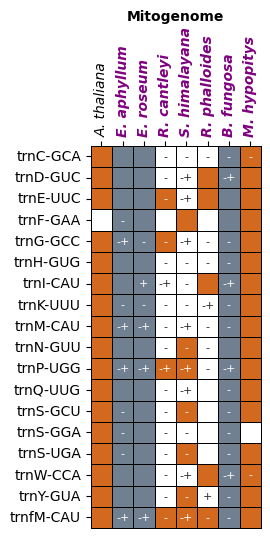

In [14]:
#Plot mitochondrial tRNA presence/absence, organellar aaRS presence/absence, and retargeting of cytosolic aaRS

#Set some parameters
holo = ['E. aphyllum','E. roseum','R. cantleyi','S. himalayana','R. phalloides','B. fungosa','M. hypopitys']
mitolabels = aaRS2.loc[aaRS2['Genome']=='mitochondrion',['A. thaliana','E. aphyllum','E. roseum','R. cantleyi','S. himalayana','R. phalloides','B. fungosa','M. hypopitys']].to_numpy() # - means lost org enzyme, + means retarget cytosolic, +/- means both
ratio = len(mito_tRNAs)/len(chloro_tRNAs)
radcolors =['slategrey','white','chocolate']
radcolors2 =['white','darkgreen']

#Do plotting
fig = plt.figure(figsize =(4, ratio*8) )
mitotarget = sns.heatmap(mito_tRNAs,cmap=radcolors,linewidths=.5, linecolor='black',square=True,cbar=False,clip_on=False,annot = mitolabels, fmt="s",annot_kws={"size": 8}) 
mitotarget.set_xlabel("Mitogenome", fontweight="bold") 
mitotarget.set_ylabel("", fontweight="bold")
mitotarget.xaxis.tick_top() # x axis on top
mitotarget.xaxis.set_label_position('top')
mitotarget.set_xticklabels(mitotarget.get_xticklabels(), rotation=90,fontsize = 10)
mitotarget.set_yticklabels(mitotarget.get_yticklabels(),fontsize = 10)
for text in mitotarget.get_xticklabels():
    text.set_style('italic')
    if text.get_text() in holo:
        text.set_weight('bold')
        text.set_color('purple')
plt.savefig('20240820_absence_presence_mitotRNAs.svg', dpi=600)

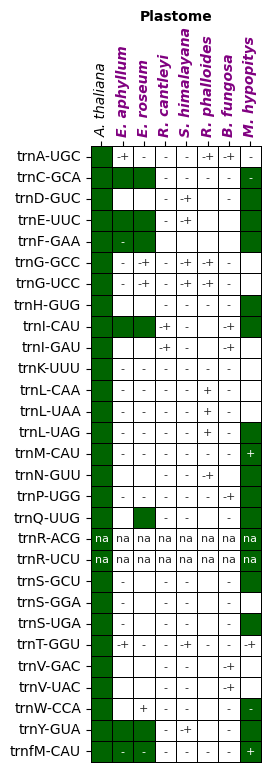

In [15]:
#Plot plastid tRNA presence/absence, organellar aaRS presence/absence, and retargeting of cytosolic aaRS
chlorolabels = aaRS2.loc[aaRS2['Genome']=='plastid',['A. thaliana','E. aphyllum','E. roseum','R. cantleyi','S. himalayana','R. phalloides','B. fungosa','M. hypopitys']].to_numpy() # - means lost org enzyme, + means retarget cytosolic, +/- means both

fig = plt.figure(figsize =(4,8))
chlorotarget = sns.heatmap(chloro_tRNAs,cmap=radcolors2,linewidths=.5,cbar=False,square=True, linecolor='black', clip_on=False, annot = chlorolabels, fmt="s",annot_kws={"size": 8}) 
chlorotarget.set_yticklabels(chlorotarget.get_yticklabels(),fontsize = 10)
chlorotarget.set_xlabel("Plastome", fontweight="bold") 
chlorotarget.yaxis.set_label_position("right")
chlorotarget.set_ylabel("", fontweight="bold")
chlorotarget.xaxis.tick_top() # x axis on top
chlorotarget.xaxis.set_label_position('top')
chlorotarget.set_xticklabels(chlorotarget.get_xticklabels(), rotation=90,fontsize = 10)
chlorotarget.set_yticklabels(chlorotarget.get_yticklabels(),fontsize = 10)
for text in chlorotarget.get_xticklabels():
    text.set_style('italic')
    if text.get_text() in holo:
        text.set_weight('bold')
        text.set_color('purple')

plt.savefig('20240820_absence_presence_chloroRNAs.svg', dpi=600)